In [2]:
# Import required libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/business_data.csv')
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
# Descriptive Statistics for Total_Sales
print("--- DESCRIPTIVE STATISTICS: Total_Sales ---")
print(f"Mean: {df['Total_Sales'].mean():.2f}")
print(f"Median: {df['Total_Sales'].median():.2f}")
print(f"Mode: {df['Total_Sales'].mode()[0]:.2f}")
print(f"Standard Deviation: {df['Total_Sales'].std():.2f}")
print(f"Variance: {df['Total_Sales'].var():.2f}")
print(f"Min: {df['Total_Sales'].min()}")
print(f"Max: {df['Total_Sales'].max()}")

# Quick summary using pandas built-in function
print("\n--- Quick Summary (describe) ---")
print(df['Total_Sales'].describe())

--- DESCRIPTIVE STATISTICS: Total_Sales ---
Mean: 123650.48
Median: 97955.50
Mode: 6540.00
Standard Deviation: 100161.09
Variance: 10032243003.46
Min: 6540
Max: 373932

--- Quick Summary (describe) ---
count       100.000000
mean     123650.480000
std      100161.085275
min        6540.000000
25%       39517.500000
50%       97955.500000
75%      175792.500000
max      373932.000000
Name: Total_Sales, dtype: float64


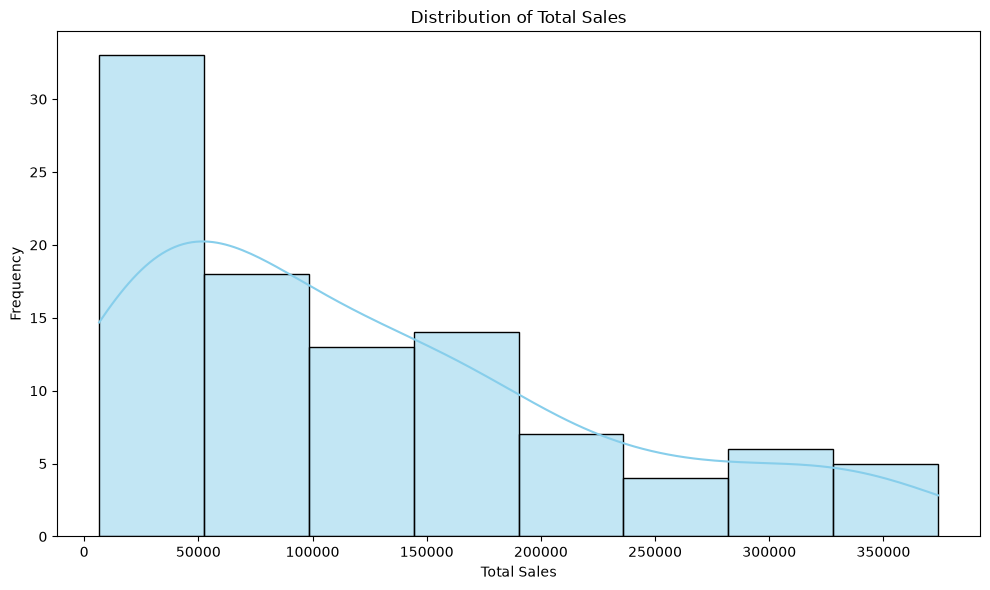

In [4]:
# Histogram to check data distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Total_Sales'], kde=True, color='skyblue')
plt.title('Distribution of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('visualizations/distribution.png')
plt.show()

--- CORRELATION MATRIX ---
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


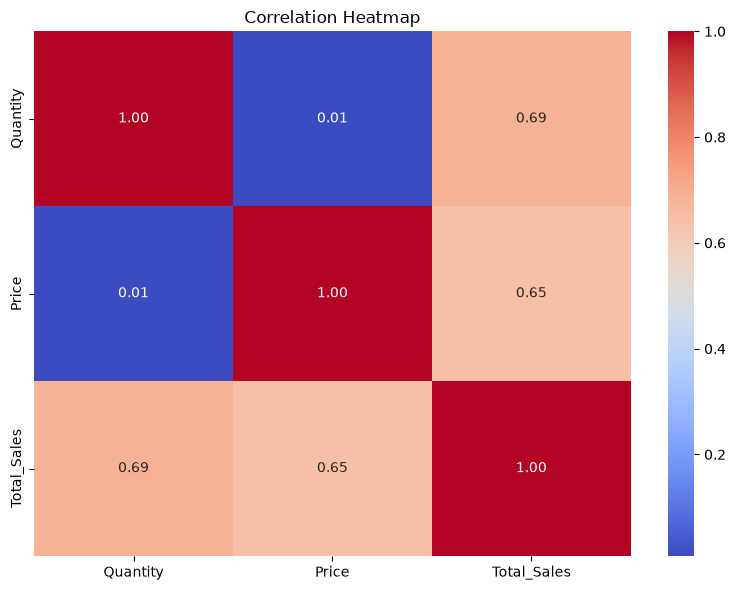

In [5]:
# Correlation between numerical columns
numeric_cols = df[['Quantity', 'Price', 'Total_Sales']]
correlation_matrix = numeric_cols.corr()

print("--- CORRELATION MATRIX ---")
print(correlation_matrix)

# Visualize with heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png')
plt.show()


In [6]:
# ============================================
# HYPOTHESIS TEST 1: T-Test (Compare North vs South sales)
# ============================================

north_sales = df[df['Region'] == 'North']['Total_Sales']
south_sales = df[df['Region'] == 'South']['Total_Sales']

t_stat, p_value = stats.ttest_ind(north_sales, south_sales)

print("--- T-TEST: North vs South Sales ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: SIGNIFICANT difference between North and South sales (p < 0.05)")
else:
    print("Result: NO significant difference between North and South sales (p >= 0.05)")

--- T-TEST: North vs South Sales ---
T-Statistic: 0.1303
P-Value: 0.8968
Result: NO significant difference between North and South sales (p >= 0.05)


In [7]:
# ============================================
# HYPOTHESIS TEST 2: ANOVA (Compare all regions)
# ============================================

region_groups = [group['Total_Sales'].values for name, group in df.groupby('Region')]

f_stat, p_value_anova = stats.f_oneway(*region_groups)

print("--- ANOVA: All Regions Sales Comparison ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Result: SIGNIFICANT difference exists among regions (p < 0.05)")
else:
    print("Result: NO significant difference among regions (p >= 0.05)")

--- ANOVA: All Regions Sales Comparison ---
F-Statistic: 2.1644
P-Value: 0.0972
Result: NO significant difference among regions (p >= 0.05)


In [8]:
# ============================================
# HYPOTHESIS TEST 3: Correlation Significance
# ============================================

corr_coef, p_value_corr = stats.pearsonr(df['Quantity'], df['Total_Sales'])

print("--- CORRELATION TEST: Quantity vs Total_Sales ---")
print(f"Correlation Coefficient: {corr_coef:.4f}")
print(f"P-Value: {p_value_corr:.4f}")

if p_value_corr < 0.05:
    print("Result: SIGNIFICANT correlation (p < 0.05)")
else:
    print("Result: NO significant correlation (p >= 0.05)")

--- CORRELATION TEST: Quantity vs Total_Sales ---
Correlation Coefficient: 0.6881
P-Value: 0.0000
Result: SIGNIFICANT correlation (p < 0.05)


In [9]:
# ============================================
# CONFIDENCE INTERVAL: Average Sales (95%)
# ============================================

mean_sales = df['Total_Sales'].mean()
sem = stats.sem(df['Total_Sales'])  # Standard Error of Mean
confidence_interval = stats.t.interval(0.95, len(df['Total_Sales'])-1, 
                                         loc=mean_sales, scale=sem)

print("--- 95% CONFIDENCE INTERVAL: Average Sales ---")
print(f"Mean Sales: {mean_sales:.2f}")
print(f"95% CI: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")
print(f"Margin of Error: ±{(confidence_interval[1] - mean_sales):.2f}")

--- 95% CONFIDENCE INTERVAL: Average Sales ---
Mean Sales: 123650.48
95% CI: (103776.35, 143524.61)
Margin of Error: ±19874.13


--- LINEAR REGRESSION: Quantity vs Total_Sales ---
Slope: 26629.54
Intercept: -3638.74
R-squared: 0.4735
P-Value: 0.0000


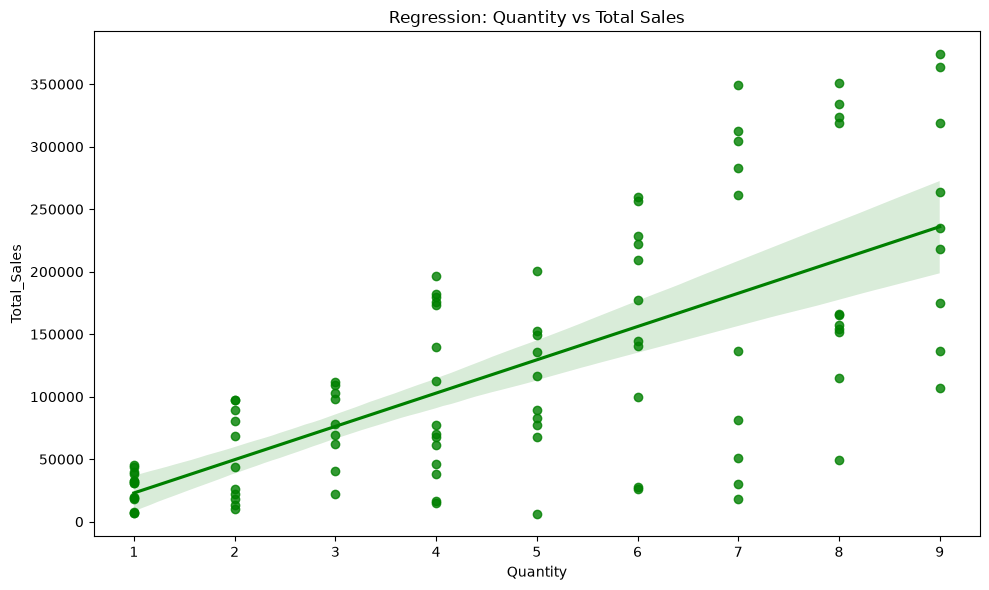

In [11]:
# ============================================
# REGRESSION ANALYSIS: Quantity predicting Total_Sales
# ============================================

from scipy.stats import linregress

slope, intercept, r_value, p_value_reg, std_err = linregress(df['Quantity'], df['Total_Sales'])

print("--- LINEAR REGRESSION: Quantity vs Total_Sales ---")
print(f"Slope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-Value: {p_value_reg:.4f}")

# Visualize regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Quantity', y='Total_Sales', data=df, color='green')
plt.title('Regression: Quantity vs Total Sales')
plt.tight_layout()

In [12]:
print("="*50)
print("   STATISTICAL ANALYSIS REPORT")
print("="*50)
print(f"Average Sales: ₹{mean_sales:,.2f} ± ₹{(confidence_interval[1]-mean_sales):,.2f} (95% CI)")
print(f"Correlation (Quantity-Sales): {corr_coef:.2f} (Significant)")
print(f"Regression R-squared: {r_value**2:.4f}")
print(f"Regional Difference: Not Significant (p={p_value_anova:.4f})")
print("="*50)

   STATISTICAL ANALYSIS REPORT
Average Sales: ₹123,650.48 ± ₹19,874.13 (95% CI)
Correlation (Quantity-Sales): 0.69 (Significant)
Regression R-squared: 0.4735
Regional Difference: Not Significant (p=0.0972)
